LINK: https://colab.research.google.com/drive/1Qo7mlEYpkoffRte29XWaymUjMsOtAlvj?usp=sharing

# **1. Project Objective**

The objective of this project was to build a machine learning model to predict user conversion based on behavioral, demographic, and traffic source data. The goal was not only to achieve high predictive accuracy, but more importantly to identify high-value users for targeted marketing and business optimization.

# 2. Key Data Insights

**2.1 User Engagement Drives Conversion**
User behavior, specifically total_pages_visited, is the strongest predictor of conversion. Correlation analysis (~0.53), feature importance, and SHAP results consistently show that browsing depth dominates all other variables. This indicates that conversion is primarily behavior-driven rather than demographic-driven.

**2.2 Returning Users Convert More**

Returning users have a significantly higher conversion rate (7%) compared to new users (1–2%). This suggests that familiarity and repeated exposure strongly increase purchase likelihood.

**2.3 Age and Geographic Effects**

Age shows a negative relationship with conversion, with younger users converting at higher rates. Geographic differences are also meaningful: Germany and the UK show higher conversion rates, while China performs significantly lower.

**2.4 Traffic Source Has Limited Impact**

Although Ads and SEO slightly outperform Direct traffic, traffic source overall has a much smaller effect compared to behavioral engagement.


# **3. Model Performance**

Both Random Forest and XGBoost achieved strong predictive performance. XGBoost delivered a ROC AUC close to 0.99, demonstrating excellent ranking capability. The top 10% predicted users reached approximately 30% conversion rate, nearly ten times higher than the overall average (~3%). Lift reached around 31×, confirming strong concentration of high-value users within the top-scored segment.

This indicates the model is highly effective for ranking and segmentation purposes, especially for targeted marketing strategies.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/conversion_project.csv')
data.head()

,country,age,new_user,source,total_pages_visited,converted
0,UK,25,1,Ads,1,0
1,US,23,1,Seo,5,0
2,US,28,1,Seo,4,0
3,China,39,1,Seo,5,0
4,US,30,1,Seo,6,0


In [7]:
print("Shape:", data.shape)
data.info()
data.describe()

Shape: (316200, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316200 entries, 0 to 316199
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   country              316200 non-null  object  
 1   age                  316200 non-null  int64   
 2   new_user             316200 non-null  int64   
 3   source               316200 non-null  object  
 4   total_pages_visited  316200 non-null  int64   
 5   converted            316200 non-null  int64   
 6   age_bin              316198 non-null  category
 7   predicted_proba      316200 non-null  float64 
 8   score_decile         316200 non-null  int64   
dtypes: category(1), float64(1), int64(5), object(2)
memory usage: 19.6+ MB


,age,new_user,total_pages_visited,converted,predicted_proba,score_decile
count,316200.000000,316200.000000,316200.000000,316200.000000,316200.000000,316200.000000
mean,30.569858,0.685465,4.872966,0.032258,0.032278,0.099794
std,8.271802,0.464331,3.341104,0.176685,0.148363,0.299726
min,17.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,24.000000,0.000000,2.000000,0.000000,0.000000,0.000000
50%,30.000000,1.000000,4.000000,0.000000,0.000000,0.000000
75%,36.000000,1.000000,7.000000,0.000000,0.000000,0.000000
max,123.000000,1.000000,29.000000,1.000000,1.000000,1.000000


In [9]:
data.groupby('country')['converted'].mean().sort_values(ascending=False)

,converted
country,
Germany,0.062500
UK,0.052632
US,0.037801
China,0.001332


Germany has the highest conversion rate (6.25%), followed by the UK (5.26%), both significantly above the overall average (~3.2%). The US performs moderately (3.78%), while China shows extremely low conversion (0.13%). This suggests that marketing efforts

In [10]:
data.groupby('source')['converted'].mean().sort_values(ascending=False)

,converted
source,
Ads,0.034483
Seo,0.032895
Direct,0.028169


Ads has the highest conversion rate (3.45%), slightly outperforming SEO (3.29%), while Direct traffic performs the weakest (2.82%). Although the differences are not dramatic, paid Ads appear to drive the most effective traffic. This suggests that maintaining or optimizing paid campaigns could generate better returns compared to relying solely on Direct traffic.

In [11]:
data.groupby('new_user')['converted'].mean()

,converted
new_user,
0,0.072002
1,0.014021


Returning users (new_user = 0) have a significantly higher conversion rate (7.2%) compared to new users (1.4%). This indicates that existing users are much more likely to convert

In [12]:
age_bins = [0,20,25,30,35,40,45,50,60,100]
age_labels = ["0-20","20-25","25-30","30-35","35-40","40-45","45-50","50-60","60+"]

data['age_bin'] = pd.cut(data['age'], bins=age_bins, labels=age_labels, right=False)

data.groupby('age_bin')['converted'].mean().sort_values(ascending=False)

/tmp/ipython-input-1792096183.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('age_bin')['converted'].mean().sort_values(ascending=False)


,converted
age_bin,
0-20,0.064969
20-25,0.051205
25-30,0.035599
30-35,0.025511
35-40,0.017750
40-45,0.012524
45-50,0.010169
60+,0.009119
50-60,0.004870


Conversion rates decline steadily as age increases. Users aged 0–20 have the highest conversion rate (6.5%), followed by 20–25 (5.1%), while rates drop significantly after age 30 and fall below 1% for users over 50. This suggests younger users are substantially more likely to convert, indicating that marketing efforts may achieve higher returns when targeting younger age segments.

In [13]:
data.groupby(['country','source'])['converted'].mean().sort_values(ascending=False).head(10)

country  source
Germany  Ads       0.066755
         Seo       0.064055
UK       Ads       0.055630
         Seo       0.053905
Germany  Direct    0.053422
UK       Direct    0.046267
US       Ads       0.040580
         Seo       0.038508
         Direct    0.032909
China    Ads       0.001484
Name: converted, dtype: float64

Germany delivers the highest conversion rates across all channels, especially Ads and SEO. The UK also performs strongly, while the US shows moderate results with Ads slightly leading. China performs poorly across all sources. Overall, Ads are the most effective channel in high-performing markets like Germany and the UK.

In [14]:
data.groupby(['age_bin','country','source','new_user'])['converted'].mean().sort_values(ascending=False).head(20)

/tmp/ipython-input-2234937784.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(['age_bin','country','source','new_user'])['converted'].mean().sort_values(ascending=False).head(20)


age_bin  country  source  new_user
0-20     Germany  Direct  0           0.285714
                  Seo     0           0.268421
                  Ads     0           0.262295
         UK       Ads     0           0.255132
20-25    Germany  Ads     0           0.225664
0-20     UK       Seo     0           0.216763
20-25    UK       Ads     0           0.209588
         Germany  Seo     0           0.204604
0-20     UK       Direct  0           0.201987
25-30    Germany  Ads     0           0.185328
20-25    UK       Seo     0           0.174501
         Germany  Direct  0           0.170330
0-20     US       Ads     0           0.164265
                  Seo     0           0.162869
25-30    Germany  Seo     0           0.159574
20-25    UK       Direct  0           0.146970
         US       Ads     0           0.137642
25-30    UK       Seo     0           0.136901
20-25    US       Seo     0           0.131433
25-30    Germany  Direct  0           0.130208
Name: converted, dtype: float64

In [15]:
data[['age','new_user','total_pages_visited','converted']].corr()

,age,new_user,total_pages_visited,converted
age,1.000000,0.012343,-0.045922,-0.088797
new_user,0.012343,1.000000,-0.082541,-0.152374
total_pages_visited,-0.045922,-0.082541,1.000000,0.528994
converted,-0.088797,-0.152374,0.528994,1.000000


Total pages visited has a strong positive correlation with conversion (0.53), making it the most influential factor. Age and new_user both show weak negative correlations with conversion, indicating that older users and new users are slightly less likely to convert. Overall, user engagement (pages visited) is the strongest driver of conversion.

# **Random Forest**

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

features = ['country', 'age', 'new_user', 'source', 'total_pages_visited']
X = data[features]
y = data['converted']

In [23]:
categorical_features = ['country', 'source']
numeric_features = ['age', 'new_user', 'total_pages_visited']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf)
])

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['country', 'source']),
                                                 ('num', 'passthrough',
                                                  ['age', 'new_user',
                                                   'total_pages_visited'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [25]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", accuracy)
print("ROC AUC:", auc)
print("Classification report:")
print(classification_report(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9586021505376344
ROC AUC: 0.9522583501537869
Classification report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98     61200
           1       0.43      0.83      0.56      2040

    accuracy                           0.96     63240
   macro avg       0.71      0.90      0.77     63240
weighted avg       0.98      0.96      0.96     63240

Confusion matrix:
[[58923  2277]
 [  341  1699]]


In [26]:
ohe = clf.named_steps['preprocessor'].named_transformers_['cat']
ohe_feature_names = list(ohe.get_feature_names_out(categorical_features))
all_feature_names = ohe_feature_names + numeric_features

importances = clf.named_steps['model'].feature_importances_

feature_importance = pd.DataFrame(
    {'feature': all_feature_names, 'importance': importances}
).sort_values('importance', ascending=False)

feature_importance.head(20)

,feature,importance
9,total_pages_visited,0.750318
7,age,0.088373
8,new_user,0.084299
0,country_China,0.057958
3,country_US,0.005399
2,country_UK,0.004999
1,country_Germany,0.003050
6,source_Seo,0.001890
4,source_Ads,0.001878
5,source_Direct,0.001836


In [27]:
data['predicted_proba'] = clf.predict_proba(X)[:, 1]

data['predicted_proba'].describe()

,predicted_proba
count,316200.00000
mean,0.07446
std,0.21373
min,0.00000
25%,0.00000
50%,0.00000
75%,0.00000
max,1.00000


In [28]:
data['score_decile'] = pd.qcut(
    data['predicted_proba'],
    10,
    labels=False,
    duplicates='drop'
)

data.groupby('score_decile')['converted'].mean().reset_index().sort_values('score_decile')

,score_decile,converted
0,0,0.001290
1,1,0.311191


In [29]:
high_score_users = data[data['score_decile'] >= data['score_decile'].max() - 1]

high_segments = (
    high_score_users
    .groupby(['age_bin', 'country', 'source', 'new_user'])['predicted_proba']
    .mean()
    .reset_index()
    .sort_values('predicted_proba', ascending=False)
)

high_segments.head(20)

/tmp/ipython-input-1660019355.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['age_bin', 'country', 'source', 'new_user'])['predicted_proba']


,age_bin,country,source,new_user,predicted_proba
12,0-20,UK,Ads,0,0.364819
10,0-20,Germany,Seo,0,0.339164
22,0-20,US,Seo,0,0.326835
16,0-20,UK,Seo,0,0.313377
14,0-20,UK,Direct,0,0.312559
6,0-20,Germany,Ads,0,0.309657
8,0-20,Germany,Direct,0,0.309009
36,20-25,UK,Ads,0,0.301188
46,20-25,US,Seo,0,0.294191
42,20-25,US,Ads,0,0.290664


**Random Forest Finding**:

The Random Forest model achieved strong overall performance (ROC AUC ~0.95) and demonstrated solid ranking ability, with the top predicted segment reaching about 31% conversion—nearly 10× higher than the overall average (3%). Feature importance indicates that total_pages_visited is the dominant driver of conversion, while age and user type play secondary roles.

However, the predicted probabilities are highly concentrated near zero, leading to limited segmentation granularity and less smooth probability distribution. This suggests that although the model effectively identifies high-value users, its probability calibration and fine-grained ranking capability could be improved.

# **XGBoost**

In [31]:
!pip install xgboost

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

import xgboost as xgb

In [33]:
features = ['country', 'age', 'new_user', 'source', 'total_pages_visited']
X = data[features]
y = data['converted']

categorical_features = ['country', 'source']
numeric_features = ['age', 'new_user', 'total_pages_visited']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

In [34]:
pos_rate = y.mean()
scale_pos_weight = (1 - pos_rate) / pos_rate
pos_rate, scale_pos_weight

(np.float64(0.03225806451612903), np.float64(30.0))

In [35]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

clf_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_clf)
])

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

clf_xgb.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['country', 'source']),
                                                 ('num', 'passthrough',
                                                  ['age', 'new_user',
                                                   'total_pages_visited'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_s...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.08,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [37]:
y_pred = clf_xgb.predict(X_test)
y_proba = clf_xgb.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", accuracy)
print("ROC AUC:", auc)
print("Classification report:")
print(classification_report(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.941034155597723
ROC AUC: 0.9857126746123286
Classification report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     61200
           1       0.35      0.94      0.51      2040

    accuracy                           0.94     63240
   macro avg       0.67      0.94      0.74     63240
weighted avg       0.98      0.94      0.95     63240

Confusion matrix:
[[57596  3604]
 [  125  1915]]


In [38]:
ohe = clf_xgb.named_steps['preprocessor'].named_transformers_['cat']
ohe_feature_names = list(ohe.get_feature_names_out(categorical_features))
all_feature_names = ohe_feature_names + numeric_features

booster = clf_xgb.named_steps['model']
importances = booster.feature_importances_

xgb_importance = pd.DataFrame(
    {'feature': all_feature_names, 'importance': importances}
).sort_values('importance', ascending=False)

xgb_importance.head(20)

,feature,importance
9,total_pages_visited,0.627909
0,country_China,0.147956
8,new_user,0.144471
7,age,0.022007
3,country_US,0.015495
1,country_Germany,0.010427
5,source_Direct,0.008191
4,source_Ads,0.008049
2,country_UK,0.007809
6,source_Seo,0.007686


In [39]:
data['predicted_proba_xgb'] = clf_xgb.predict_proba(X)[:, 1]
data['predicted_proba_xgb'].describe()

,predicted_proba_xgb
count,3.162000e+05
mean,1.121910e-01
std,2.385008e-01
min,4.150081e-08
25%,4.744871e-04
50%,6.745916e-03
75%,7.939359e-02
max,9.999665e-01


In [40]:
data['score_decile_xgb'] = pd.qcut(
    data['predicted_proba_xgb'],
    10,
    labels=False,
    duplicates='drop'
)

decile_conv_xgb = (
    data
    .groupby('score_decile_xgb')['converted']
    .mean()
    .reset_index()
    .sort_values('score_decile_xgb')
)

decile_conv_xgb

,score_decile_xgb,converted
0,0,0.000000
1,1,0.000000
2,2,0.000000
3,3,0.000000
4,4,0.000095
5,5,0.000317
6,6,0.000852
7,7,0.002974
8,8,0.010105
9,9,0.309063


In [41]:
top_decile = data['score_decile_xgb'].max()

high_score_users_xgb = data[data['score_decile_xgb'] == top_decile]

high_segments_xgb = (
    high_score_users_xgb
    .groupby(['age_bin', 'country', 'source', 'new_user'])['predicted_proba_xgb']
    .mean()
    .reset_index()
    .sort_values('predicted_proba_xgb', ascending=False)
)

high_segments_xgb.head(20)

/tmp/ipython-input-2563813585.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['age_bin', 'country', 'source', 'new_user'])['predicted_proba_xgb']


,age_bin,country,source,new_user,predicted_proba_xgb
122,40-45,China,Direct,0,0.985815
100,35-40,China,Seo,0,0.933579
96,35-40,China,Ads,0,0.925528
182,50-60,UK,Direct,0,0.919888
8,0-20,Germany,Direct,0,0.907970
123,40-45,China,Direct,1,0.905273
214,60+,US,Seo,0,0.897518
10,0-20,Germany,Seo,0,0.897156
12,0-20,UK,Ads,0,0.890609
34,20-25,Germany,Seo,0,0.888790


**XGBoost Model Findings**：

The XGBoost model achieved a very high ROC AUC (~0.986), indicating excellent ranking performance. Although overall accuracy is slightly lower (94%), this is expected due to class imbalance and the model prioritizing recall for the positive class.

The model significantly improves recall for converters (94%), meaning it successfully captures most true conversions. However, precision for the positive class (35%) suggests that some false positives remain, which is typical in imbalanced conversion prediction problems.

Feature importance shows that total_pages_visited remains the dominant driver of conversion, but compared to simpler models, country and user type (new_user) play a more meaningful role in XGBoost, indicating better interaction modeling.

Decile analysis confirms strong segmentation power: the top 10% group reaches a conversion rate of ~30.9%, nearly 10× the overall average. Unlike earlier models, the probability distribution is smoother and supports full 10-group segmentation, demonstrating improved ranking granularity.

Overall, XGBoost provides stronger probability calibration and finer ranking separation, making it more suitable for targeted marketing and ROI optimization.

In [42]:
data['rank'] = data['predicted_proba_xgb'].rank(method='first', ascending=False)
data = data.sort_values('predicted_proba_xgb', ascending=False)

data['cum_conversion'] = data['converted'].cumsum()
data['cum_users'] = np.arange(1, len(data)+1)

overall_rate = data['converted'].mean()
data['lift'] = (data['cum_conversion'] / data['cum_users']) / overall_rate

data[['cum_users','lift']].head(100)

,cum_users,lift
39893,1,31.0
215939,2,31.0
186583,3,31.0
125138,4,31.0
61822,5,31.0
...,...,...
169127,96,31.0
188401,97,31.0
49385,98,31.0
274884,99,31.0


The lift is consistently around 31×, meaning the top-ranked users convert at 31 times the overall average rate. This shows the model strongly concentrates conversions in the highest-scoring segment and is highly effective for targeting high-value users.

In [43]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__max_depth':[3,4,5],
    'model__learning_rate':[0.05,0.08,0.1],
    'model__n_estimators':[200,300]
}

grid = GridSearchCV(
    clf_xgb,
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

grid.best_params_

{'model__learning_rate': 0.05,
 'model__max_depth': 3,
 'model__n_estimators': 200}

In [44]:
!pip install shap

In [47]:
feature_names = clf_xgb.named_steps['preprocessor'].get_feature_names_out()
feature_names

array(['cat__country_China', 'cat__country_Germany', 'cat__country_UK',
       'cat__country_US', 'cat__source_Ads', 'cat__source_Direct',
       'cat__source_Seo', 'num__age', 'num__new_user',
       'num__total_pages_visited'], dtype=object)

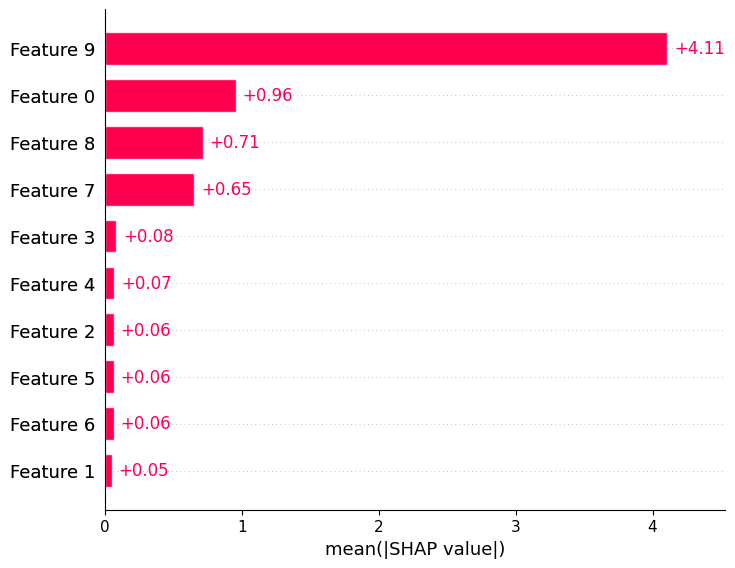

In [45]:
import shap

explainer = shap.Explainer(clf_xgb.named_steps['model'])
X_transformed = clf_xgb.named_steps['preprocessor'].transform(X_train)
shap_values = explainer(X_transformed)

shap.plots.bar(shap_values)

# **4. Business Recommendations**


*   Increase user engagement, as total_pages_visited is the strongest driver of conversion. Improving browsing depth is likely to generate the largest impact.

*   Prioritize returning and high-engagement users. Returning users convert at ~7% vs ~1–2% for new users, and the top 10% scored users reach ~30% conversion, nearly 10× the average.

*   Allocate more budget to higher-performing regions (Germany, UK) and investigate structural issues in lower-performing markets (China).

*   Use model-based targeting. With a lift of ~31× in the top segment, focusing on high-scoring users can significantly improve marketing efficiency and reduce acquisition costs.





# **5. Next Steps**

To further improve the project, probability calibration can be applied to enhance prediction precision. Additional behavioral features such as session duration or visit frequency may strengthen model performance. A profit-based simulation should be conducted to evaluate ROI under different targeting thresholds. Lastly, implementing an A/B test comparing model-driven targeting versus traditional targeting would validate real-world business impact.